# Projet 3 — Backtesting d'une stratégie systématique
## Notebook 00 — Pipeline de données

**Rôle de cette phase dans le projet.** Avant d'écrire la moindre ligne de stratégie ou de moteur, il faut un jeu de données **propre, ajusté et figé**. Tout le reste (backtester vectoriel en Phase 1, moteur événementiel en Phase 2, stratégies en Phase 4, évaluation en Phase 5) consommera les fichiers produits ici. Une erreur de données à ce stade se propage silencieusement dans tout le projet et invalide les résultats. C'est le même réflexe que pour le pricer : on sécurise les fondations d'abord.

**Ce que ce notebook produit :**
- `data/prices_raw.parquet` : les cours bruts téléchargés (Open/High/Low/Close/Adj Close/Volume), archivés pour la **reproductibilité** ;
- `data/adj_close.csv` : la matrice des **cours ajustés** (une colonne par actif) — la base de tous les calculs de rendement ;
- `data/log_returns.csv` : les rendements logarithmiques journaliers ;
- un premier diagnostic visuel (séries normalisées, corrélations, aperçu du spread KO/PEP).

> Ce notebook doit être exécuté **sur ta machine avec accès Internet** (yfinance interroge Yahoo Finance). Une fois le `.parquet` archivé, les exécutions suivantes rechargent le fichier local : les figures et valeurs ne bougent plus entre deux runs.


## 0. Les notions clés de la Phase 0 (rappel court)

Ces notions sont détaillées dans le guide qui accompagne ce notebook. En résumé :

- **Systématique vs discrétionnaire** : une stratégie systématique applique une règle explicite et reproductible ; aucune décision humaine « au feeling ». C'est ce qui rend le backtest possible.
- **Signal → position → ordre** : le *signal* est la sortie de la règle (ex. « moyenne courte > moyenne longue »), la *position* est l'exposition détenue (long / flat / short), l'*ordre* est la transaction qui fait passer d'une position à une autre.
- **Backtest vectoriel vs événementiel** : le vectoriel calcule tout d'un coup avec pandas (rapide, mais expose au *look-ahead bias*) ; l'événementiel rejoue l'histoire pas à pas via une file d'événements (fidèle à la réalité). On fera les deux (Phases 1 et 2).
- **Les 4 péchés du backtest** : *look-ahead bias*, *survivorship bias*, *sur-apprentissage / data snooping*, oubli des **coûts**. Cette phase en neutralise déjà deux (données ajustées contre les erreurs de prix, archivage figé contre le look-ahead d'exécution).
- **Cours ajusté vs cours brut** : le point technique le plus important ici. Détaillé en section 3.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yfinance as yf
except ImportError:
    raise ImportError("Installe yfinance : pip install yfinance")

import statsmodels.api as sm

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
DATA_DIR = "../data"
os.makedirs(DATA_DIR, exist_ok=True)
print("Environnement prêt.")

Environnement prêt.


## 1. Configuration : l'univers d'actifs

Deux blocs distincts, un par stratégie du projet.

**Univers momentum (suivi de tendance par croisement de moyennes).** Huit grandes capitalisations américaines, très liquides, réparties sur plusieurs secteurs. La liquidité garantit des cours de qualité et des coûts de transaction réalistes (spreads serrés) ; la diversité sectorielle évite qu'un seul thème (ex. la tech) ne pilote tous les résultats et donne de la **dispersion transversale**, utile pour une logique de tendance.

| Ticker | Société | Secteur |
|---|---|---|
| AAPL | Apple | Technologie |
| MSFT | Microsoft | Technologie / logiciel |
| NVDA | NVIDIA | Semi-conducteurs |
| AMZN | Amazon | Consommation discrétionnaire |
| JPM  | JPMorgan Chase | Finance |
| XOM  | ExxonMobil | Énergie |
| JNJ  | Johnson & Johnson | Santé |
| PG   | Procter & Gamble | Consommation de base |

**Paire pour le pairs trading : KO / PEP.** Coca-Cola et PepsiCo appartiennent au même secteur (boissons / consommation de base), subissent les mêmes chocs macro (coût des intrants, cycle de consommation) et sont donc **économiquement liées**. C'est le cas d'école de la cointégration : leurs cours peuvent diverger à court terme mais tendent à revenir vers une relation d'équilibre commune, ce qui crée un spread moyen-réversif exploitable.

**Benchmark : SPY** (ETF répliquant le S&P 500). Il servira de référence *buy & hold* en Phase 5 : une stratégie n'a de valeur que comparée à « ne rien faire d'autre qu'acheter l'indice ».


In [2]:
# --- Univers ---
MOMENTUM_UNIVERSE = ["AAPL", "MSFT", "NVDA", "AMZN", "JPM", "XOM", "JNJ", "PG"]
PAIR = ["KO", "PEP"]
BENCHMARK = ["SPY"]

ALL_TICKERS = sorted(set(MOMENTUM_UNIVERSE + PAIR + BENCHMARK))

# --- Période ---
# Historique long : couvrir plusieurs régimes de marché (2010s haussier, choc COVID 2020,
# resserrement 2022) et laisser de la marge pour un découpage train / test walk-forward.
START = "2010-01-01"
END   = None  # None = jusqu'à aujourd'hui

print(f"{len(ALL_TICKERS)} actifs à télécharger :", ALL_TICKERS)
print(f"Période : {START} -> {'aujourd hui' if END is None else END}")

11 actifs à télécharger : ['AAPL', 'AMZN', 'JNJ', 'JPM', 'KO', 'MSFT', 'NVDA', 'PEP', 'PG', 'SPY', 'XOM']
Période : 2010-01-01 -> aujourd hui


## 2. Téléchargement (avec archivage pour reproductibilité)

On télécharge une seule fois puis on archive dans `data/prices_raw.parquet`. Les exécutions suivantes rechargent ce fichier au lieu de réinterroger Yahoo : le jeu de données est **figé**, donc reproductible. Pour rafraîchir les données volontairement, il suffit de supprimer le fichier ou de passer `force_download=True`.

On récupère `auto_adjust=False` pour conserver **à la fois** le cours de clôture brut (`Close`) et le cours ajusté (`Adj Close`), ce qui permet d'illustrer la différence en section 3.


In [3]:
RAW_PATH = os.path.join(DATA_DIR, "prices_raw.parquet")

def download_prices(tickers, start, end, path, force_download=False):
    if os.path.exists(path) and not force_download:
        print(f"Chargement du cache local : {path}")
        return pd.read_parquet(path)
    print("Téléchargement via yfinance...")
    raw = yf.download(
        tickers, start=start, end=end,
        auto_adjust=False, group_by="column",
        progress=False, threads=True,
    )
    if raw.empty:
        raise RuntimeError("Téléchargement vide. Vérifie ta connexion et les tickers.")
    raw.to_parquet(path)
    print(f"Archivé : {path}  (shape={raw.shape})")
    return raw

raw = download_prices(ALL_TICKERS, START, END, RAW_PATH)
print("Colonnes (niveau champ) :", list(raw.columns.get_level_values(0).unique()))
raw.tail(3)

Téléchargement via yfinance...
Archivé : ../data\prices_raw.parquet  (shape=(4177, 66))
Colonnes (niveau champ) : ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


Price      Adj Close                                                       \
Ticker          AAPL     AMZN      JNJ      JPM      KO     MSFT     NVDA   
Date                                                                        
2026-08-10  308.2600 278.0900 261.8100 359.7900 86.8700 506.0600 217.5500   
2026-08-11  304.9100 272.2700 259.8000 362.0400 86.4800 503.8100 217.5000   
2026-08-12  301.8200 268.7300 261.0400 365.7450 86.8350 494.1801 222.5200   

Price                                  ...    Volume                    \
Ticker          PEP       PG      SPY  ...      AMZN      JNJ      JPM   
Date                                   ...                               
2026-08-10 137.7300 146.4400 773.0300  ...  35731900  8985100  5327500   
2026-08-11 138.4100 145.2100 770.5600  ...  31895700  5945900  4576500   
2026-08-12 138.6900 144.5583 772.9100  ...  21611647  2583029  2640741   

Price                                                                  \
Ticker            KO      MSFT       NVDA      PEP       PG       SPY   
Date                                                                    
2026-08-10  13710800  31206100  115846600  5883800  7386500  39249500   
2026-08-11  16018000  23049800  101273100  5823900  7936700  36740600   
2026-08-12   7621485  17267117   82247924  3698567  4494027  22968724   

Price                 
Ticker           XOM  
Date                  
2026-08-10  19761600  
2026-08-11  13744500  
2026-08-12   5802187  

[3 rows x 66 columns]

## 3. Cours brut vs cours ajusté — le point de données le plus important

Le **cours brut** (`Close`) est le prix affiché en clôture. Il ignore les **dividendes** et les **splits**. Or :

- un jour de détachement de dividende, le cours chute mécaniquement du montant du dividende : le cours brut affiche une « perte » qui n'en est pas une (l'actionnaire a touché le dividende) ;
- un split 4-pour-1 divise le cours brut par 4 du jour au lendemain : le cours brut affiche un « krach » de -75 % totalement fictif.

Le **cours ajusté** (`Adj Close`) corrige ces deux effets rétroactivement, de sorte que la **variation du cours ajusté = rendement réellement perçu par l'investisseur** (réinvestissement des dividendes inclus). 

**Règle absolue pour un backtest : on calcule les rendements sur le cours ajusté, jamais sur le cours brut.** Utiliser le cours brut fabrique de faux signaux les jours de dividende / split et fausse toutes les performances.


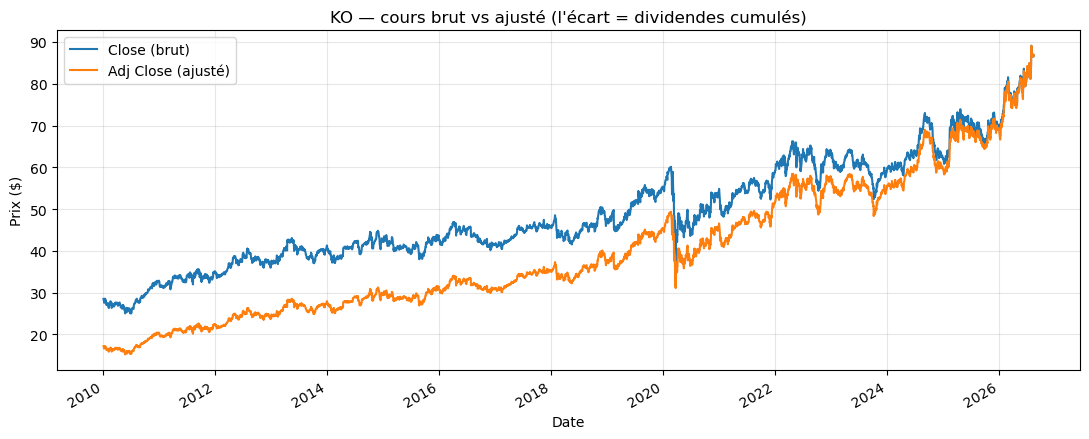

Écart brut-ajusté en début de période pour KO : 11.31 $ (dividendes + splits accumulés depuis)


In [4]:
# Extraction robuste des champs (gère le MultiIndex de yfinance)
def get_field(raw, field):
    if isinstance(raw.columns, pd.MultiIndex):
        return raw[field].copy()
    # cas 1 seul ticker : pas de MultiIndex
    return raw[[field]].copy()

close_raw = get_field(raw, "Close")
adj_close = get_field(raw, "Adj Close")

# Illustration sur un titre versant des dividendes (KO) : écart brut vs ajusté
t = "KO"
comp = pd.DataFrame({"Close (brut)": close_raw[t], "Adj Close (ajusté)": adj_close[t]}).dropna()
ax = comp.plot(title=f"{t} — cours brut vs ajusté (l'écart = dividendes cumulés)")
ax.set_ylabel("Prix ($)"); plt.tight_layout(); plt.show()

ecart = (comp["Close (brut)"] - comp["Adj Close (ajusté)"]).iloc[0]
print(f"Écart brut-ajusté en début de période pour {t} : {ecart:.2f} $ "
      f"(dividendes + splits accumulés depuis)")

## 4. Nettoyage et alignement

Trois opérations, chacune justifiée :

1. **Dédoublonnage / tri de l'index** : on garantit un index temporel strictement croissant et sans doublon.
2. **Comblement des trous courts** (`ffill` limité à 5 jours) : un jour férié décalé ou une donnée manquante ponctuelle est reportée depuis la veille. On **limite** volontairement à 5 jours pour ne pas inventer de longues périodes de prix figés (ce qui masquerait un vrai problème de données).
3. **Suppression des lignes incomplètes restantes** : on aligne tous les actifs sur les dates où **tous** ont une valeur. Un backtest multi-actifs a besoin d'un panneau (*panel*) aligné.

> Note d'honnêteté méthodologique : notre univers ne contient que des sociétés **encore cotées aujourd'hui**. C'est un **biais du survivant** assumé (on ne teste pas sur des sociétés faillies ou sorties de cote). Pour un projet portfolio c'est acceptable, mais on le **documentera explicitement** dans le rapport — le signaler est déjà une marque de maturité.


In [5]:
def quality_report(df, label=""):
    rep = pd.DataFrame({
        "n_obs": df.notna().sum(),
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(2),
        "start": df.apply(lambda s: s.first_valid_index()),
        "end": df.apply(lambda s: s.last_valid_index()),
    })
    print(f"--- Rapport qualité {label} ---")
    return rep

quality_report(adj_close, "(avant nettoyage)")

--- Rapport qualité (avant nettoyage) ---


,n_obs,n_missing,pct_missing,start,end
Ticker,,,,,
AAPL,4177,0,0.0000,2010-01-04,2026-08-12
AMZN,4177,0,0.0000,2010-01-04,2026-08-12
JNJ,4177,0,0.0000,2010-01-04,2026-08-12
JPM,4177,0,0.0000,2010-01-04,2026-08-12
KO,4177,0,0.0000,2010-01-04,2026-08-12
MSFT,4177,0,0.0000,2010-01-04,2026-08-12
NVDA,4177,0,0.0000,2010-01-04,2026-08-12
PEP,4177,0,0.0000,2010-01-04,2026-08-12
PG,4177,0,0.0000,2010-01-04,2026-08-12


In [6]:
def clean_prices(df, ffill_limit=5):
    df = df[~df.index.duplicated(keep="first")].sort_index()
    df = df.ffill(limit=ffill_limit)
    df = df.dropna(how="any")
    return df

adj_clean = clean_prices(adj_close)
print("Shape après nettoyage :", adj_clean.shape)
print("Valeurs manquantes restantes :", int(adj_clean.isna().sum().sum()))
print(f"Période effective alignée : {adj_clean.index.min().date()} -> {adj_clean.index.max().date()}")
quality_report(adj_clean, "(après nettoyage)")

Shape après nettoyage : (4177, 11)
Valeurs manquantes restantes : 0
Période effective alignée : 2010-01-04 -> 2026-08-12
--- Rapport qualité (après nettoyage) ---


,n_obs,n_missing,pct_missing,start,end
Ticker,,,,,
AAPL,4177,0,0.0000,2010-01-04,2026-08-12
AMZN,4177,0,0.0000,2010-01-04,2026-08-12
JNJ,4177,0,0.0000,2010-01-04,2026-08-12
JPM,4177,0,0.0000,2010-01-04,2026-08-12
KO,4177,0,0.0000,2010-01-04,2026-08-12
MSFT,4177,0,0.0000,2010-01-04,2026-08-12
NVDA,4177,0,0.0000,2010-01-04,2026-08-12
PEP,4177,0,0.0000,2010-01-04,2026-08-12
PG,4177,0,0.0000,2010-01-04,2026-08-12


## 5. Rendements logarithmiques

On travaille en **rendements logarithmiques** $r_t = \ln(P_t / P_{t-1})$ plutôt qu'arithmétiques, pour deux raisons pratiques :

- ils sont **additifs dans le temps** : le rendement cumulé sur une période est la simple somme des rendements journaliers, ce qui simplifie l'agrégation et le calcul des courbes d'équité ;
- ils sont mieux adaptés aux hypothèses de normalité utilisées plus tard (tests statistiques, Sharpe).

Pour de petits mouvements journaliers, $\ln(1+x) \approx x$, donc l'écart avec le rendement arithmétique reste minime.


In [7]:
log_returns = np.log(adj_clean).diff().dropna()
print("Rendements log — shape :", log_returns.shape)
log_returns.describe().T[["mean", "std", "min", "max"]]

Rendements log — shape : (4176, 11)


,mean,std,min,max
Ticker,,,,
AAPL,0.0009,0.0177,-0.1377,0.1426
AMZN,0.0009,0.0207,-0.1514,0.1462
JNJ,0.0004,0.0107,-0.1058,0.0769
JPM,0.0006,0.0173,-0.1621,0.1656
KO,0.0004,0.0109,-0.1017,0.0628
MSFT,0.0007,0.0164,-0.1595,0.1442
NVDA,0.0015,0.0285,-0.2077,0.2609
PEP,0.0003,0.0112,-0.1214,0.1217
PG,0.0003,0.0110,-0.0914,0.1134


## 6. Premiers diagnostics visuels

### 6.1 Trajectoires normalisées (base 100)
Toutes les séries ramenées à 100 au départ : on compare la **croissance relative** sur toute la période, indépendamment du niveau de prix.


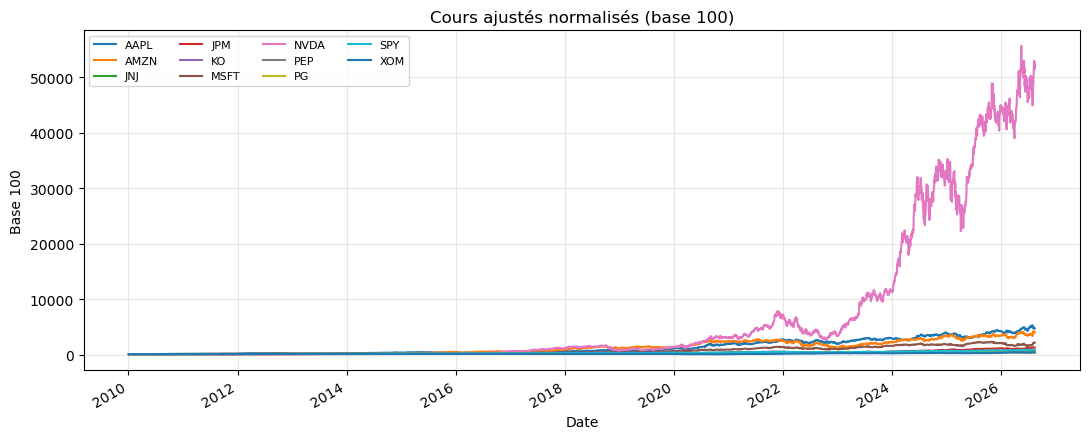

In [8]:
norm = adj_clean / adj_clean.iloc[0] * 100
ax = norm.plot(title="Cours ajustés normalisés (base 100)")
ax.set_ylabel("Base 100"); ax.legend(ncol=4, fontsize=8); plt.tight_layout(); plt.show()

### 6.2 Corrélation des rendements
La matrice de corrélation des rendements journaliers donne une première idée des redondances (les valeurs tech corrèlent entre elles, KO et PEP devraient corréler fortement).


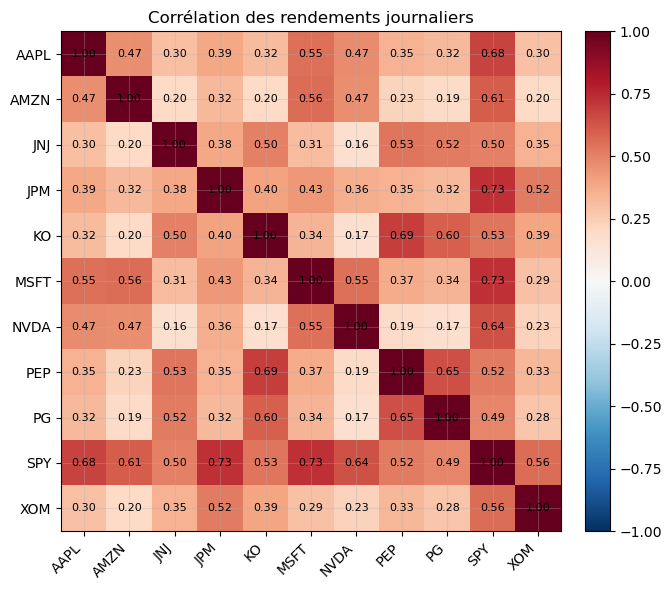

In [9]:
corr = log_returns.corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Corrélation des rendements journaliers")
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

### 6.3 Aperçu du couple KO / PEP et du spread
On anticipe la Phase 4. On estime un **ratio de couverture** $\beta$ par régression OLS de PEP sur KO, puis on construit le **spread** $= \text{PEP} - (\alpha + \beta \cdot \text{KO})$ et son **z-score** glissant. Les seuils $\pm 2$ matérialisent les futures zones d'entrée du pairs trading.

> Ceci n'est qu'un **aperçu visuel** : le vrai test de cointégration (Engle-Granger), le choix de la fenêtre et la demi-vie de réversion seront traités proprement en Phase 4. L'objectif ici est juste de vérifier que la paire « ressemble » à une paire cointégrée.


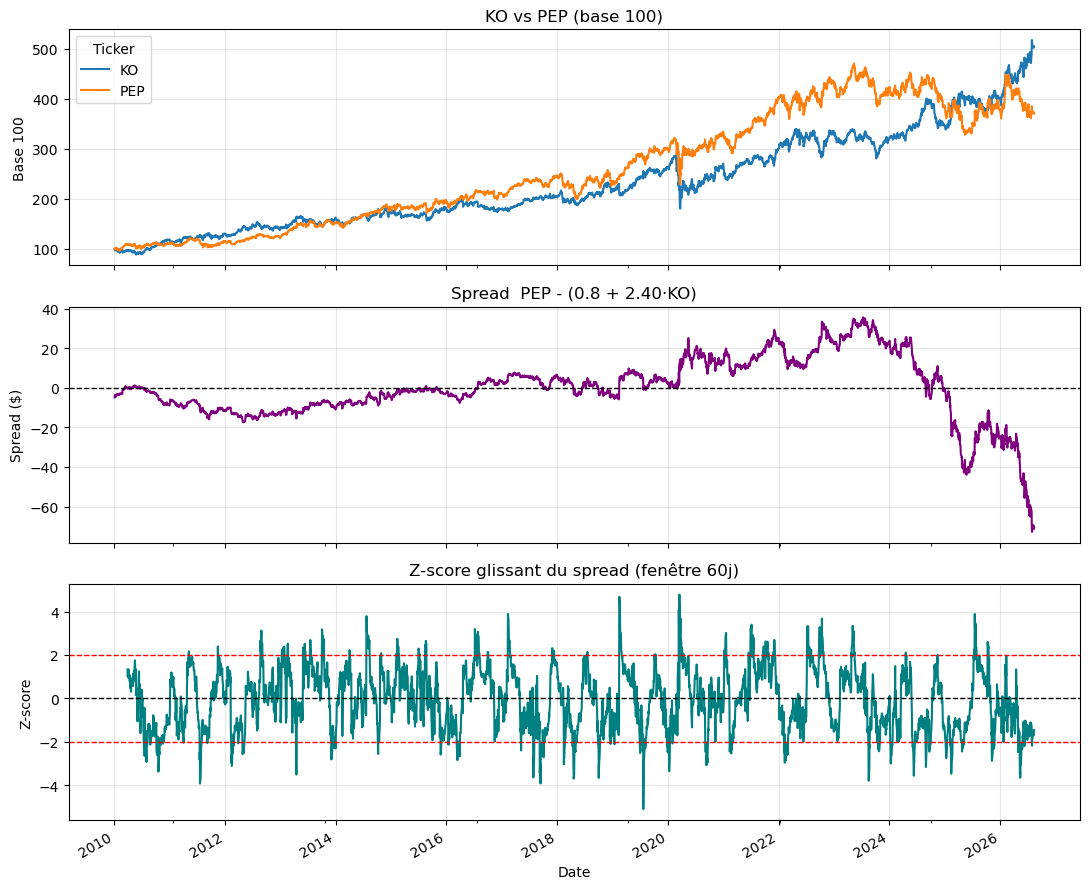

Ratio de couverture estimé : beta = 2.398, alpha = 0.834
Jours où |z| > 2 (signaux potentiels) : 570


In [10]:
ko, pep = adj_clean["KO"], adj_clean["PEP"]

# Ratio de couverture par OLS : PEP = alpha + beta * KO + spread
X = sm.add_constant(ko)
ols = sm.OLS(pep, X).fit()
alpha, beta = ols.params["const"], ols.params["KO"]
spread = pep - (alpha + beta * ko)

WIN = 60  # fenêtre glissante (~3 mois de bourse)
zscore = (spread - spread.rolling(WIN).mean()) / spread.rolling(WIN).std()

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
(adj_clean[["KO", "PEP"]] / adj_clean[["KO", "PEP"]].iloc[0] * 100).plot(
    ax=axes[0], title="KO vs PEP (base 100)"); axes[0].set_ylabel("Base 100")
spread.plot(ax=axes[1], color="purple", title=f"Spread  PEP - ({alpha:.1f} + {beta:.2f}·KO)")
axes[1].axhline(spread.mean(), color="k", ls="--", lw=1); axes[1].set_ylabel("Spread ($)")
zscore.plot(ax=axes[2], color="teal", title=f"Z-score glissant du spread (fenêtre {WIN}j)")
for lvl, c in [(2, "r"), (-2, "r"), (0, "k")]:
    axes[2].axhline(lvl, color=c, ls="--", lw=1)
axes[2].set_ylabel("Z-score"); plt.tight_layout(); plt.show()

print(f"Ratio de couverture estimé : beta = {beta:.3f}, alpha = {alpha:.3f}")
print(f"Jours où |z| > 2 (signaux potentiels) : {int((zscore.abs() > 2).sum())}")

## 7. Sauvegarde des jeux de données

On archive les fichiers propres dans `data/`. Ce sont eux que les notebooks suivants (01 à 05) et le futur package `src/` chargeront. On ne re-télécharge plus rien.


In [11]:
adj_clean.to_csv(os.path.join(DATA_DIR, "adj_close.csv"))
log_returns.to_csv(os.path.join(DATA_DIR, "log_returns.csv"))

print("Fichiers écrits dans data/ :")
for f in ["prices_raw.parquet", "adj_close.csv", "log_returns.csv"]:
    p = os.path.join(DATA_DIR, f)
    if os.path.exists(p):
        print(f"  - {f}  ({os.path.getsize(p)/1024:.0f} Ko)")

Fichiers écrits dans data/ :
  - prices_raw.parquet  (1848 Ko)
  - adj_close.csv  (870 Ko)
  - log_returns.csv  (1012 Ko)


## 8. Récapitulatif et prochaine étape

**Ce qu'on a sécurisé en Phase 0 :**
- un univers d'actifs justifié (8 large caps pour le momentum, KO/PEP pour le pairs trading, SPY en benchmark) ;
- des cours **ajustés** (dividendes / splits corrigés) — la condition d'un backtest correct ;
- un panel **aligné et nettoyé**, archivé et **figé** pour la reproductibilité ;
- un premier aperçu qui confirme que KO/PEP se comporte comme une paire cointégrée.

**Phase 1 (prochaine) — backtester vectoriel.** On construit un premier backtester simple en pandas sur le croisement de moyennes mobiles, en soignant le décalage du signal (`shift(1)`) pour éviter le *look-ahead bias*. Objectif : obtenir une première courbe d'équité et comprendre la mécanique signal → position → rendement avant de passer à l'architecture événementielle (Phase 2).

> Rappel d'architecture : les fonctions `clean_prices`, `quality_report`, `download_prices` migreront vers `src/data.py` en Phase 2 pour devenir le `DataHandler` du moteur. On garde tout modulaire dès maintenant.
